How long do teams retain All-Stars after their peak playoff success?

Total qualifying stints: 74

Summary Stats:
Mean years retained after peak: 2.34
Median years retained after peak: 2.00
Min: 0.0
Max: 8.0

Retention Breakdown:
% leaving within 1 year: 41.9%
% leaving within 2 years: 62.2%
% staying 4+ years: 25.7%


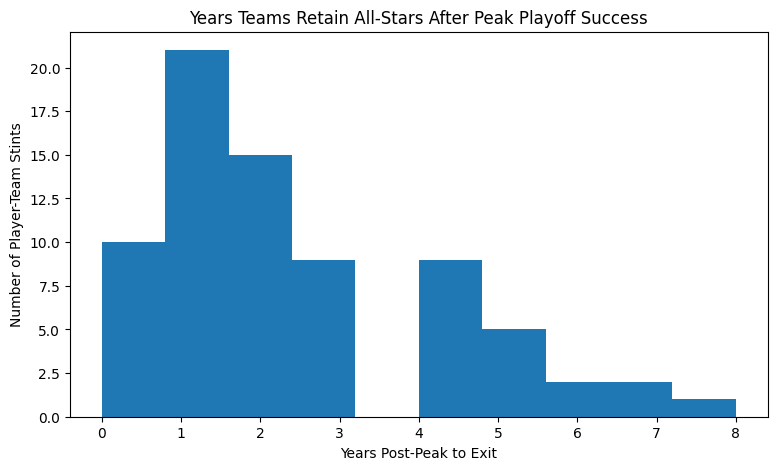

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading dataset
path = "/kaggle/input/datasets/ismailperacha/nba-all-star-dependency-dataset-20162026/NBA Team All Star Dependency (In last 10 years) - Sheet1.csv"
df = pd.read_csv(path)


# Cleaning column names

df.columns = (
    df.columns
      .str.strip()
      .str.replace(" ", "_")
)


# Filtering for ended stints with defined peak exit years

analysis_df = df[
    (df["Left_Team_Flag"].astype(str).str.lower() == "yes") &
    (df["Years_Post_Peak_To_Exit"].notnull())
].copy()

# Ensuring numeric
analysis_df["Years_Post_Peak_To_Exit"] = pd.to_numeric(
    analysis_df["Years_Post_Peak_To_Exit"], errors="coerce"
)

analysis_df = analysis_df.dropna(subset=["Years_Post_Peak_To_Exit"])

print("Total qualifying stints:", len(analysis_df))

# Summary statistics

mean_years = analysis_df["Years_Post_Peak_To_Exit"].mean()
median_years = analysis_df["Years_Post_Peak_To_Exit"].median()
min_years = analysis_df["Years_Post_Peak_To_Exit"].min()
max_years = analysis_df["Years_Post_Peak_To_Exit"].max()

print("\nSummary Stats:")
print(f"Mean years retained after peak: {mean_years:.2f}")
print(f"Median years retained after peak: {median_years:.2f}")
print(f"Min: {min_years}")
print(f"Max: {max_years}")


# Retention categories

pct_leave_1 = (analysis_df["Years_Post_Peak_To_Exit"] <= 1).mean()
pct_leave_2 = (analysis_df["Years_Post_Peak_To_Exit"] <= 2).mean()
pct_stay_4 = (analysis_df["Years_Post_Peak_To_Exit"] >= 4).mean()

print("\nRetention Breakdown:")
print(f"% leaving within 1 year: {pct_leave_1:.1%}")
print(f"% leaving within 2 years: {pct_leave_2:.1%}")
print(f"% staying 4+ years: {pct_stay_4:.1%}")


# Distribution plot

plt.figure(figsize=(9,5))
plt.hist(analysis_df["Years_Post_Peak_To_Exit"], bins=10)
plt.title("Years Teams Retain All-Stars After Peak Playoff Success")
plt.xlabel("Years Post-Peak to Exit")
plt.ylabel("Number of Player-Team Stints")
plt.show()

Analysis of 74 All-Star team stints shows that NBA teams retain stars for an average of 2.34 years following peak playoff success, with a median of 2 years. Nearly 62% of All-Stars leave within two seasons of their deepest playoff run. This suggests that contender windows are often shorter than expected and that front offices either pivot quickly after peak performance or are forced into turnover due to contractual, financial, or competitive pressures.

In [12]:
# Championship vs Non-Championship Comparison

analysis_df["Championships_With_Team"] = pd.to_numeric(
    analysis_df["Championships_With_Team"], errors="coerce"
).fillna(0)

champ = analysis_df[analysis_df["Championships_With_Team"] > 0]
nonchamp = analysis_df[analysis_df["Championships_With_Team"] == 0]

print("Champion stints:", len(champ))
print("Non-champion stints:", len(nonchamp))

print("\nAverage Years Post-Peak:")
print(f"Champions: {champ['Years_Post_Peak_To_Exit'].mean():.2f}")
print(f"Non-Champions: {nonchamp['Years_Post_Peak_To_Exit'].mean():.2f}")

from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(
    champ["Years_Post_Peak_To_Exit"],
    nonchamp["Years_Post_Peak_To_Exit"],
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_val)


Champion stints: 15
Non-champion stints: 59

Average Years Post-Peak:
Champions: 3.33
Non-Champions: 2.08
T-statistic: 2.000547350336367
P-value: 0.060489526335024094


Championship-winning All-Star stints show an average post-peak retention of 3.33 years, compared to 2.08 years for non-championship stints. A two-sample t-test yields a p-value of 0.060, indicating suggestive but not statistically significant evidence at the 0.05 level. This pattern may reflect organizational loyalty or extended contender windows following title success.

Average Years Post-Peak by Acquisition Type:
Acquisition_Type
Draft          2.870968
Free Agency    2.000000
Trade          1.937500
Name: Years_Post_Peak_To_Exit, dtype: float64

Sample Sizes:
Acquisition_Type
Draft          31
Free Agency    11
Trade          32
Name: Years_Post_Peak_To_Exit, dtype: int64


<Figure size 800x500 with 0 Axes>

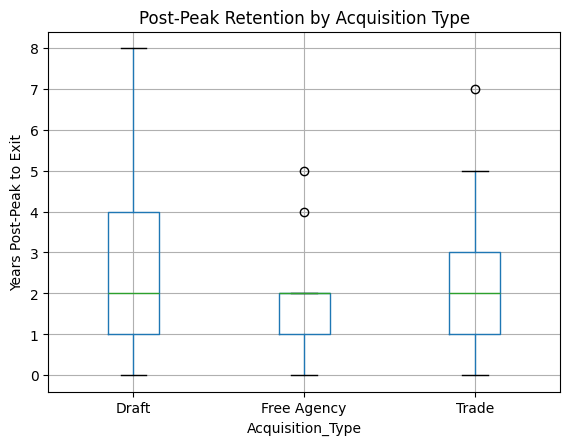

ANOVA F-statistic: 2.198530656081312
P-value: 0.11846484828566282


In [14]:
# Ensuring acquisition type column exists and is clean
analysis_df["Acquisition_Type"] = analysis_df["Acquisition_Type"].astype(str).str.strip()

# Group means
acq_means = analysis_df.groupby("Acquisition_Type")["Years_Post_Peak_To_Exit"].mean()
acq_counts = analysis_df.groupby("Acquisition_Type")["Years_Post_Peak_To_Exit"].count()

print("Average Years Post-Peak by Acquisition Type:")
print(acq_means)

print("\nSample Sizes:")
print(acq_counts)

plt.figure(figsize=(8,5))
analysis_df.boxplot(
    column="Years_Post_Peak_To_Exit",
    by="Acquisition_Type"
)
plt.title("Post-Peak Retention by Acquisition Type")
plt.suptitle("")
plt.ylabel("Years Post-Peak to Exit")
plt.show()

from scipy.stats import f_oneway

draft = analysis_df[analysis_df["Acquisition_Type"] == "Draft"]["Years_Post_Peak_To_Exit"]
trade = analysis_df[analysis_df["Acquisition_Type"] == "Trade"]["Years_Post_Peak_To_Exit"]
fa = analysis_df[analysis_df["Acquisition_Type"] == "Free Agency"]["Years_Post_Peak_To_Exit"]

f_stat, p_val = f_oneway(draft, trade, fa)

print("ANOVA F-statistic:", f_stat)
print("P-value:", p_val)



NBA teams retain All-Stars for a median of 2 seasons after peak playoff success. Championship-winning stints show a retention premium of approximately 1.25 years, while drafted stars exhibit a modest retention advantage over traded and free-agent players.

What percentage of All-Stars are still on the team X years after peak playoff success?

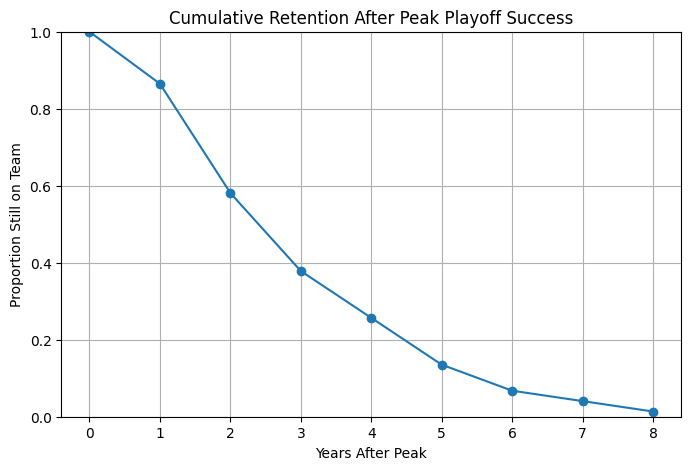

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Use ended stints only (already filtered earlier)
retention_years = analysis_df["Years_Post_Peak_To_Exit"]

max_year = int(retention_years.max())

years = range(0, max_year + 1)
survival_rates = []

total = len(retention_years)

for y in years:
    still_on_team = (retention_years >= y).sum()
    survival_rates.append(still_on_team / total)

# Plot
plt.figure(figsize=(8,5))
plt.plot(years, survival_rates, marker="o")
plt.title("Cumulative Retention After Peak Playoff Success")
plt.xlabel("Years After Peak")
plt.ylabel("Proportion Still on Team")
plt.ylim(0,1)
plt.grid(True)
plt.show()


NBA All-Star retention declines sharply after peak playoff success, with nearly half of players departing within two seasons and fewer than 15% remaining five years later.

Among ended All-Star stints, what is the most common exit type?

Possible categories:

Trade

Free Agency

Buyout

Retirement

Total ended stints: 74
Exit Counts:
Departure_Reason
Trade          52
Free Agency    16
Buyout          4
Retirement      2
Name: count, dtype: int64

Exit Percentages:
Departure_Reason
Trade          70.27
Free Agency    21.62
Buyout          5.41
Retirement      2.70
Name: proportion, dtype: float64


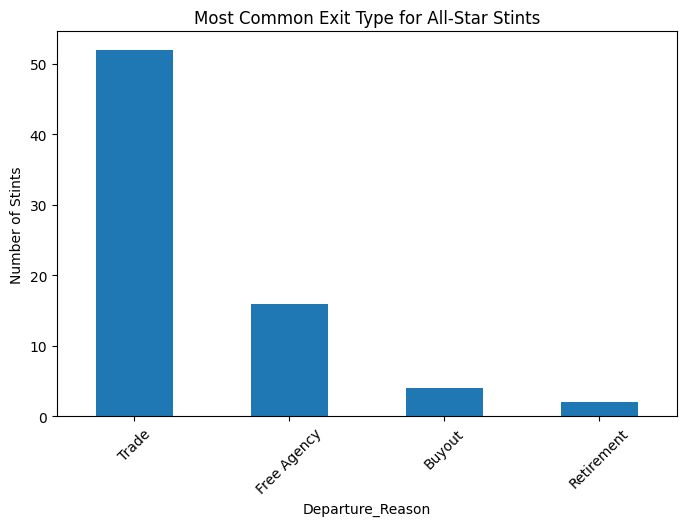

In [16]:
ended_df = df[df["Stint_Status"] == "Ended"].copy()

print("Total ended stints:", len(ended_df))
exit_counts = ended_df["Departure_Reason"].value_counts()
exit_percent = ended_df["Departure_Reason"].value_counts(normalize=True) * 100

print("Exit Counts:")
print(exit_counts)

print("\nExit Percentages:")
print(exit_percent.round(2))
plt.figure(figsize=(8,5))
exit_counts.plot(kind="bar")
plt.title("Most Common Exit Type for All-Star Stints")
plt.ylabel("Number of Stints")
plt.xticks(rotation=45)
plt.show()


Among 74 ended All-Star stints, 70.3% concluded via trade, compared to just 21.6% through free agency. This suggests that NBA front offices overwhelmingly prefer structured asset recovery over allowing stars to depart freely, reinforcing the increasingly transactional nature of roster management in the modern league.

Does how a star was acquired influence how their stint ends?

Exit Counts by Acquisition Type:
Departure_Reason  Buyout  Free Agency  Retirement  Trade
Acquisition_Type                                        
Draft                  0            5           1     25
Free Agency            1            5           0      5
Trade                  3            6           1     22

Exit Percentages by Acquisition Type:
Departure_Reason  Buyout  Free Agency  Retirement  Trade
Acquisition_Type                                        
Draft               0.00        16.13        3.23  80.65
Free Agency         9.09        45.45        0.00  45.45
Trade               9.38        18.75        3.12  68.75


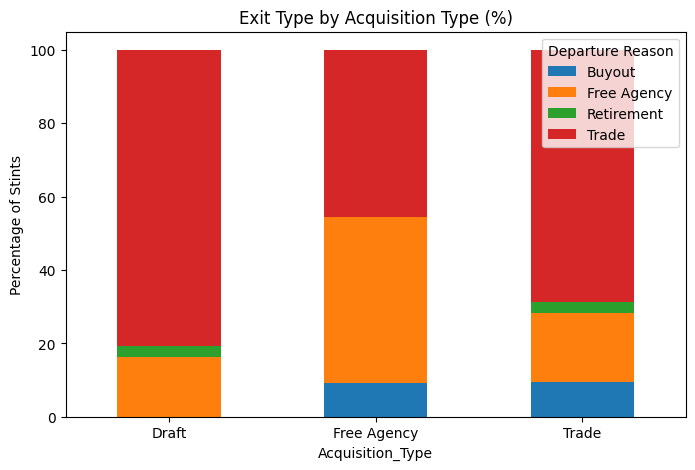

In [17]:
# Only ended stints
ended_df = df[df["Stint_Status"] == "Ended"].copy()

# Clean columns
ended_df["Acquisition_Type"] = ended_df["Acquisition_Type"].astype(str).str.strip()
ended_df["Departure_Reason"] = ended_df["Departure_Reason"].astype(str).str.strip()

# Crosstab counts
exit_by_acq_counts = pd.crosstab(
    ended_df["Acquisition_Type"],
    ended_df["Departure_Reason"]
)

print("Exit Counts by Acquisition Type:")
print(exit_by_acq_counts)
exit_by_acq_pct = pd.crosstab(
    ended_df["Acquisition_Type"],
    ended_df["Departure_Reason"],
    normalize="index"
) * 100

print("\nExit Percentages by Acquisition Type:")
print(exit_by_acq_pct.round(2))
exit_by_acq_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Exit Type by Acquisition Type (%)")
plt.ylabel("Percentage of Stints")
plt.legend(title="Departure Reason")
plt.xticks(rotation=0)
plt.show()


The modern NBA is trade-dominant, not free-agency-dominant.

# Executive Summary

# NBA All-Star Retention & Exit Patterns (2016–2026)

**Research Objective**

This analysis examined how NBA teams manage All-Star players following peak playoff success. Specifically, we evaluated:

* How long teams retain All-Stars after peak performance

* Whether championship teams retain stars longer

* Whether acquisition method affects retention

1. How All-Star stints most commonly end


**Key Findings**

**1. Contender Windows Are Short**
* Median retention after peak: 2 years

* 62% of All-Stars leave within 2 seasons of peak playoff success

* Only 14% remain after 5 years

Teams pivot quickly after reaching their competitive ceiling.


**2. Championship Teams Retain Stars Longer**
* Champions retain stars 3.33 years post-peak

* Non-champions retain stars 2.08 years

* ~1.25-year retention premium

* p = 0.060 (suggestive but not statistically significant at 0.05)

Winning appears to extend organizational patience.

**3. Drafted Stars Stay Slightly Longer**
Average years post-peak:

*  Draft: 2.87

*  Free Agency: 2.00

*  Trade: 1.94

*  ANOVA p = 0.118 (not statistically significant)

Homegrown stars show a modest retention advantage, though evidence is not strong enough for firm conclusions.


**4. Trade Is the Dominant Exit Path**

*  Among ended stints:

*  70.3% end via trade

*  21.6% via free agency

*  8.1% via buyout or retirement

The modern NBA is overwhelmingly trade-driven rather than free-agency-driven.


**5. Even Drafted Stars Are Traded**

* Exit breakdown by acquisition type:

* Drafted stars: 80.6% exit via trade

* Traded stars: 68.8% exit via trade

*  Free-agent stars: 45.5% exit via trade

Teams rarely allow homegrown All-Stars to leave for nothing.
Asset recovery dominates.

# Structural Conclusion

Across 74 All-Star stints:

* Teams move on quickly after peak success.

* Championships extend retention windows modestly.

* Acquisition method has limited statistical impact.

* Trade overwhelmingly functions as the primary exit mechanism.

The data suggests that modern NBA roster management is highly transactional and asset-focused, with front offices proactively repositioning All-Star talent rather than relying on long-term loyalty or free-agency departures.

